# Experiments for bijection sandpiles parkfunc

In [41]:
# Load the package...
load("../sorted_sandpile.py")

In [42]:
# Initialize symmetric function stuff...

R = FractionField(QQ['q, t'])      # type: ignore
q,t = R.gens()
poly = 0*q*t

In [43]:
# Construct the two graphs that should be equivalent...

mu = []
nu = [7]
nu_rev = [nu[len(nu) - i - 1] for i in range(len(nu))]
n = sum(mu) + sum(nu)
k = 2

G1 = Multi_CliqueIndependent_SortedSandpile(mu, nu, k)
G2 = Multi_CliqueIndependent_SortedSandpile(mu + nu_rev, [], k)

In [44]:
sortrec1 = G1.sorted_recurrents(option=2)
sortrec2 = G2.sorted_recurrents(option=2)

{1: 6, 2: 6, 3: 6, 4: 6, 5: 7, 6: 8, 7: 9}
False


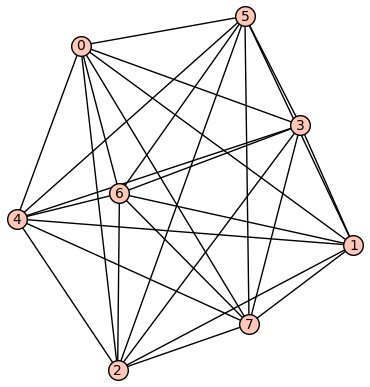

Exception: The sorted configuration is not recurrent, hence delay is not defined.

In [45]:
new_set = []

for conf1 in sortrec1:                      # Implement the correspondence
    conf2 = {}
    conf2 = conf2 | {1:conf1[1] + 0}
    conf2 = conf2 | {2:conf1[2] + 1}
    conf2 = conf2 | {3:conf1[3] + 2}
    conf2 = conf2 | {4:conf1[4] + 3}
    conf2 = conf2 | {5:conf1[5] + 0}
    conf2 = conf2 | {6:conf1[6] + 0}
    conf2 = conf2 | {7:conf1[7] + 0}
    new_set = new_set + [conf2]
    
    config1 = SandpileSortConfig(G1.sandpile_struct, conf1, G1.perm_group, verts=G1.vertices) 
    config2 = SandpileSortConfig(G2.sandpile_struct, conf2, G2.perm_group, verts=G2.vertices)  
    l1 = config1.level()
    d1 = config1.delay()
    l2 = config2.level()
    d2 = config2.delay()
    if (l1 != l2) or (d1 != d2):            # Check if the correspondence works...
        print("Config G1:\t {}\n level(c) = {} \t\t delay(c) = {}".format(conf1, l1, d1))
        print("Config G2:\t {}\n level(c) = {} \t\t delay(c) = {}\n".format(conf2, l2, d2))

# Test for Example 4.1

In [47]:
def tilde_map(mu,nu,config):
    new_conf = {}       # Define new dictionary
    n = sum(mu) + sum(nu)
    i = 0
    for part_nu in nu:
        for j in range(part_nu):
            i += 1
            new_conf = new_conf | {i:config[i]+j}
    for j in range(n-i):
        new_conf = new_conf | {i+j+1:config[i+j+1]}
    return new_conf         # !!!!!! RETURNS A DICTIONARY !!!!!!

# Construct the two graphs that should be equivalent...

mu = [4,1]
nu = [6,2]
nu_rev = [nu[len(nu) - i - 1] for i in range(len(nu))]
n = sum(mu) + sum(nu)
k = 2

G1 = Multi_CliqueIndependent_SortedSandpile(mu, nu, k)
G2 = Multi_CliqueIndependent_SortedSandpile(mu + nu_rev, [], k)

conf1 = {1:2, 2:7, 3:12, 4:15, 5:18, 6:18, 7:14, 8:17, 9:2, 10:24, 11:18, 12:17, 13:6}
conf2 = tilde_map(mu,nu,conf1)

old_conf = SandpileSortConfig(G1.sandpile_struct, conf1, G1.perm_group, verts=G1.vertices)
new_conf = SandpileSortConfig(G2.sandpile_struct, conf2, G2.perm_group, verts=G2.vertices)

print(conf2)

[del1,wtopp1,record1,word1] = old_conf.k_delay_test(info=True)
[del2,wtopp2,record2,word2] = new_conf.k_delay_test(info=True)

{1: 2, 2: 8, 3: 14, 4: 18, 5: 22, 6: 23, 7: 14, 8: 18, 9: 2, 10: 24, 11: 18, 12: 17, 13: 6}


In [48]:
print(wtopp1)
print(wtopp2)
print(record1)
print(record2)

[13, 6, 5, 13, 6, 5, 4, 12, 11, 8, 7, 4, 3, 12, 11, 8, 7, 3, 2, 10, 2, 10, 9, 1, 9, 1]
[13, 6, 5, 13, 6, 5, 4, 12, 11, 8, 7, 4, 3, 12, 11, 8, 7, 3, 2, 10, 2, 10, 9, 1, 9, 1]
[13, -1, -1, -1, -1, -1, -1, 6, 5, -1, -1, -1, -1, 13, -1, -1, -1, -1, -1, -1, 6, 5, 4, -1, -1, -1, -1, 12, 11, -1, -1, 8, 7, -1, -1, 4, 3, -1, -1, -1, 12, 11, -1, -1, 8, 7, -1, -1, -1, 3, 2, -1, -1, -1, -1, 10, -1, -1, -1, -1, -1, -1, -1, 2, -1, -1, -1, -1, 10, 9, -1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, -1, 9, -1, -1, -1, -1, -1, -1, -1, 1]
[13, -1, -1, -1, -1, -1, -1, 6, 5, -1, -1, -1, -1, 13, -1, -1, -1, -1, -1, -1, 6, 5, 4, -1, -1, -1, -1, 12, 11, -1, -1, 8, 7, -1, -1, 4, 3, -1, -1, -1, 12, 11, -1, -1, 8, 7, -1, -1, -1, 3, 2, -1, -1, -1, -1, 10, -1, -1, -1, -1, -1, -1, -1, 2, -1, -1, -1, -1, 10, 9, -1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, -1, 9, -1, -1, -1, -1, -1, -1, -1, 1]


In [51]:
print(word2)

0 & 25 & 19 & 18 & 7 & 3 & 19 & 15 & 24 & 23 & 19 & 15 & 9 & 3\\ 
13 & 13 & 20 & 19 & 8 & 4 & 20 & 16 & \textbf{ 25 } & 24 & 20 & 16 & 10 & 4\\ 
6 & 14 & 21 & 20 & 9 & 5 & 21 & 17 & 13 & \textbf{ 25 } & 21 & 17 & 11 & 5\\ 
5 & 15 & 22 & 21 & 10 & 6 & 22 & 18 & 14 & 13 & 22 & 18 & 12 & 6\\ 
13 & 2 & 23 & 22 & 11 & 7 & 23 & 19 & 15 & 14 & 23 & 19 & 13 & 7\\ 
6 & 3 & 24 & 23 & 12 & 8 & 24 & 20 & 2 & 15 & 24 & 20 & 14 & 8\\ 
5 & 4 & \textbf{ 25 } & 24 & 13 & 9 & \textbf{ 25 } & 21 & 3 & 2 & \textbf{ 25 } & 21 & 15 & 9\\ 
4 & 5 & \textbf{ 26 } & \textbf{ 25 } & 14 & 10 & \textbf{ 26 } & 22 & 4 & 3 & 13 & 22 & 16 & 10\\ 
12 & 6 & 14 & \textbf{ 26 } & 15 & 11 & \textbf{ 27 } & 23 & 5 & 4 & 14 & 23 & 17 & 11\\ 
11 & 7 & 15 & 14 & 16 & 12 & \textbf{ 28 } & 24 & 6 & 5 & 15 & 24 & 18 & 12\\ 
8 & 8 & 16 & 15 & 17 & 13 & 16 & \textbf{ 25 } & 7 & 6 & 16 & \textbf{ 25 } & 19 & 13\\ 
7 & 9 & 17 & 16 & 18 & 14 & 17 & 13 & 8 & 7 & 17 & \textbf{ 26 } & 20 & 14\\ 
4 & 10 & 18 & 17 & 19 & 15 & 18 & 14 & 9 

In [13]:
X = [6,17,18,24,2,18,14,23,22,18,14,8,2]
X.sort(reverse = True)
X = [v+2 for v in X]
X

[26, 25, 24, 20, 20, 20, 19, 16, 16, 10, 8, 4, 4]